# Classifier evaluation

Three things live in this notebook, ordered cheapest/weakest baseline first
so each section's number is a floor for the one after it:

1. **Decision tree baseline (position-only features).** No text at all --
   just where in the conversation a supporter turn falls. Floor for "how
   much does position alone explain."
2. **TF-IDF + LogReg baseline, 8-class.** Same fixed config already used for
   3-class in `01_split_protocol.ipynb` (TF-IDF max_features=20000,
   ngram_range=(1,2), LogisticRegression class_weight="balanced",
   random_state=42) -- not tuned, so evaluating it on test carries none of
   the leakage-into-decisions risk a tuned model would.
3. **DL classifier test-set evaluation.** The single, official test-set
   touch for the tuned checkpoints (RoBERTa and DistilBERT, both selected on
   val across multiple runs -- see `report_notes.md`). Requires
   `src/evaluate.py test` to have already been run once per checkpoint
   (it saves `test_predictions.csv` / `classification_report.txt` /
   `confusion_matrix.csv` under `outputs/{task}/{name}/`).

The position tree's `ccp_alpha` is also a tuned hyperparameter (selected on
val, like the DL learning rates), so its test-set evaluation is that model's
single official touch too -- same discipline throughout this notebook, not
just for the DL models.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_and_clean, build_8class_examples, build_3class_examples, flatten_context, STRATEGY_LABELS, COARSE_LABELS, STRATEGY_TO_COARSE
from data import apply_conversation_level_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix

convs = load_and_clean()

# Built once here, shared by the decision-tree and TF-IDF sections below
# (both use the same official conversation-level split, seed=42).
examples_8c = build_8class_examples(convs)
train_8c, val_8c, test_8c = apply_conversation_level_split(convs, examples_8c, seed=42)

examples_3c = build_3class_examples(convs)
train_3c, val_3c, test_3c = apply_conversation_level_split(convs, examples_3c, seed=42)

CONTRACTION_TOKEN_PATTERN = r"(?u)\b\w[\w']*\w\b"  # sklearn default r"(?u)\b\w\w+\b" splits on the apostrophe (we're -> "we","re"; that's -> "that", drops the "s") -- found while reading TF-IDF top-coefficient words; this keeps contractions whole, still drops single-char tokens like the default did.


## 1. Decision tree baseline (position-only features)

Deliberately weak, non-textual baseline: predicts strategy from *where in
the conversation* a supporter turn falls, nothing about what was said.
Answers "how much of strategy choice is explainable by position alone" as a
floor to compare the text-based baselines/DL models against -- not intended
to compete for best score.

Features (2, both derived from `conversation_id`/`turn_index`, no text):
- `normalized_position`: turn_index / (conversation length - 1)
- `supporter_turn_ordinal`: how many supporter turns (with a defined
  strategy, for this task) have occurred in the conversation up to and
  including this one

**Model selection:** grid search over `max_leaf_nodes` (explicit tree-size
cap) x `min_samples_leaf` (statistical floor -- no leaf trusted on too few
examples), selected on val macro-F1. Both are tuned hyperparameters (like
the DL learning rates), so the test-set evaluation below is that model's
single official touch.

*(Started with CART's own pruning method, cost-complexity pruning via
`ccp_alpha` -- dropped after finding it doesn't control tree size on this
data: selecting argmax(val macro-F1) over the full pruning path kept
improving all the way to a near-unpruned, 3,390-leaf tree on 8-class (~4
examples/leaf -- pure memorization, not an interpretable baseline).
Switched to directly bounding size instead. Cost of the restriction, since
this baseline was never competing for best score anyway: 0.011 macro-F1 on
8-class test, 0.0 on 3-class test -- negligible against a model that trails
the text-based baselines regardless of tree size.)*

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from collections import defaultdict


def add_position_features(examples, convs):
    """normalized_position + supporter_turn_ordinal, computed purely from
    conversation_id/turn_index -- no text involved."""
    order = sorted(range(len(examples)), key=lambda i: (examples[i]["conversation_id"], examples[i]["turn_index"]))
    ordinal_counter = defaultdict(int)
    ordinal = {}
    for i in order:
        conv_id = examples[i]["conversation_id"]
        ordinal_counter[conv_id] += 1
        ordinal[i] = ordinal_counter[conv_id]

    feats = []
    for i, ex in enumerate(examples):
        conv_len = len(convs[ex["conversation_id"]]["dialog"])
        norm_pos = ex["turn_index"] / (conv_len - 1) if conv_len > 1 else 0.0
        feats.append([norm_pos, ordinal[i]])
    return np.array(feats)


FEATURE_NAMES = ["normalized_position", "supporter_turn_ordinal"]


def fit_tree_grid(X_train, y_train, X_val, y_val, max_leaf_nodes_grid, min_samples_leaf_grid):
    """
    Grid search over two size-controlling hyperparameters, selected on val
    macro-F1: max_leaf_nodes (explicit cap on tree size, best-first growth)
    and min_samples_leaf (statistical floor -- no leaf trusted on too few
    examples). See markdown above for why this replaced ccp_alpha selection.
    Returns (best_model, all_results_sorted_by_val_f1_desc).
    """
    results = []
    for mln in max_leaf_nodes_grid:
        for msl in min_samples_leaf_grid:
            clf = DecisionTreeClassifier(criterion="gini", random_state=42, max_leaf_nodes=mln, min_samples_leaf=msl)
            clf.fit(X_train, y_train)
            val_f1 = f1_score(y_val, clf.predict(X_val), average="macro", zero_division=0)
            results.append({
                "max_leaf_nodes": mln, "min_samples_leaf": msl,
                "depth": clf.get_depth(), "leaves": clf.get_n_leaves(),
                "val_macro_f1": val_f1, "model": clf,
            })
    results.sort(key=lambda r: -r["val_macro_f1"])
    return results[0]["model"], results


### 8-class

In [3]:
X_train_8c = add_position_features(train_8c, convs)
y_train_8c = np.array([ex["gold_strategy_id"] for ex in train_8c])
X_val_8c = add_position_features(val_8c, convs)
y_val_8c = np.array([ex["gold_strategy_id"] for ex in val_8c])
X_test_8c = add_position_features(test_8c, convs)
y_test_8c = np.array([ex["gold_strategy_id"] for ex in test_8c])

MLN_GRID_8C = [7, 10, 15, 20]
MSL_GRID_8C = [20, 50, 100, 200]
tree_8c, grid_results_8c = fit_tree_grid(X_train_8c, y_train_8c, X_val_8c, y_val_8c, MLN_GRID_8C, MSL_GRID_8C)
best_8c = grid_results_8c[0]
print(f"Selected max_leaf_nodes={best_8c['max_leaf_nodes']}  min_samples_leaf={best_8c['min_samples_leaf']}  (val macro-F1={best_8c['val_macro_f1']:.4f})")
print(f"Tree: depth={tree_8c.get_depth()}  leaves={tree_8c.get_n_leaves()}")

print("\nTop grid candidates:")
for r in grid_results_8c[:6]:
    print(f"  max_leaf_nodes={r['max_leaf_nodes']:3d}  min_samples_leaf={r['min_samples_leaf']:4d}  depth={r['depth']:2d}  leaves={r['leaves']:3d}  val_f1={r['val_macro_f1']:.4f}")

test_pred_8c = tree_8c.predict(X_test_8c)
tree_8c_test_f1 = f1_score(y_test_8c, test_pred_8c, average="macro", zero_division=0)
print(f"\nTEST macro-F1 = {tree_8c_test_f1:.4f}")
print(classification_report(y_test_8c, test_pred_8c, target_names=STRATEGY_LABELS, zero_division=0))
print("Feature importances:", dict(zip(FEATURE_NAMES, tree_8c.feature_importances_)))


Selected max_leaf_nodes=20  min_samples_leaf=100  (val macro-F1=0.1771)
Tree: depth=8  leaves=20

Top grid candidates:
  max_leaf_nodes= 20  min_samples_leaf= 100  depth= 8  leaves= 20  val_f1=0.1771
  max_leaf_nodes= 20  min_samples_leaf= 200  depth= 9  leaves= 20  val_f1=0.1752
  max_leaf_nodes= 20  min_samples_leaf=  20  depth= 6  leaves= 20  val_f1=0.1736
  max_leaf_nodes= 15  min_samples_leaf= 100  depth= 6  leaves= 15  val_f1=0.1735
  max_leaf_nodes= 15  min_samples_leaf= 200  depth= 6  leaves= 15  val_f1=0.1735
  max_leaf_nodes= 20  min_samples_leaf=  50  depth= 7  leaves= 20  val_f1=0.1733

TEST macro-F1 = 0.1795
                             precision    recall  f1-score   support

Affirmation and Reassurance       0.20      0.15      0.17       267
                Information       0.00      0.00      0.00        96
                     Others       0.41      0.54      0.46       307
      Providing Suggestions       0.24      0.63      0.35       283
                   Questi

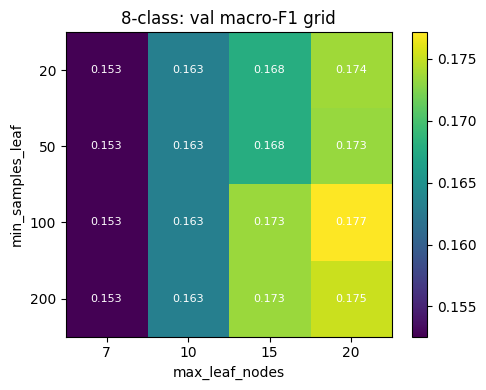

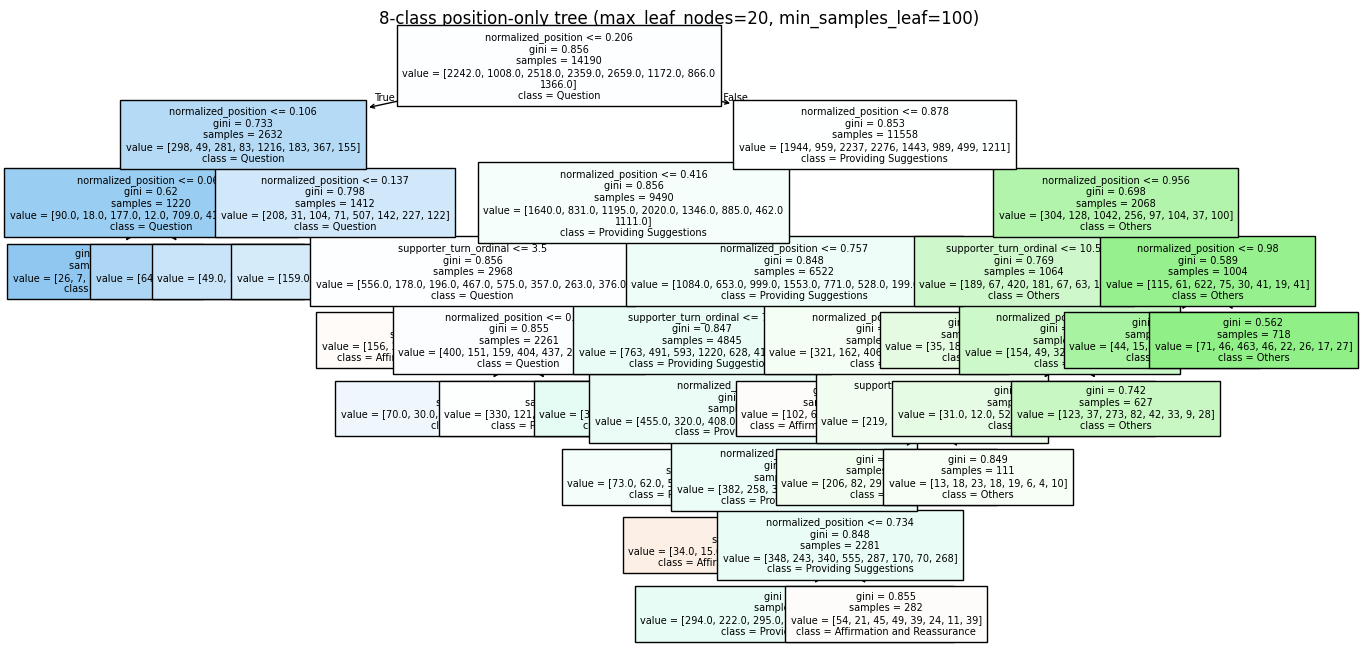

In [4]:
grid_df_8c = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in grid_results_8c])
pivot_8c = grid_df_8c.pivot(index="min_samples_leaf", columns="max_leaf_nodes", values="val_macro_f1")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot_8c.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot_8c.columns))); ax.set_xticklabels(pivot_8c.columns)
ax.set_yticks(range(len(pivot_8c.index))); ax.set_yticklabels(pivot_8c.index)
ax.set_xlabel("max_leaf_nodes"); ax.set_ylabel("min_samples_leaf")
ax.set_title("8-class: val macro-F1 grid")
for i in range(pivot_8c.shape[0]):
    for j in range(pivot_8c.shape[1]):
        ax.text(j, i, f"{pivot_8c.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_8c, feature_names=FEATURE_NAMES, class_names=STRATEGY_LABELS, filled=True, fontsize=7, ax=ax)
ax.set_title(f"8-class position-only tree (max_leaf_nodes={best_8c['max_leaf_nodes']}, min_samples_leaf={best_8c['min_samples_leaf']})")
plt.show()


### 3-class

In [5]:
X_train_3c = add_position_features(train_3c, convs)
y_train_3c = np.array([ex["gold_coarse_id"] for ex in train_3c])
X_val_3c = add_position_features(val_3c, convs)
y_val_3c = np.array([ex["gold_coarse_id"] for ex in val_3c])
X_test_3c = add_position_features(test_3c, convs)
y_test_3c = np.array([ex["gold_coarse_id"] for ex in test_3c])

MLN_GRID_3C = [3, 5, 7, 9]
MSL_GRID_3C = [20, 50, 100, 200]
tree_3c, grid_results_3c = fit_tree_grid(X_train_3c, y_train_3c, X_val_3c, y_val_3c, MLN_GRID_3C, MSL_GRID_3C)
best_3c = grid_results_3c[0]
print(f"Selected max_leaf_nodes={best_3c['max_leaf_nodes']}  min_samples_leaf={best_3c['min_samples_leaf']}  (val macro-F1={best_3c['val_macro_f1']:.4f})")
print(f"Tree: depth={tree_3c.get_depth()}  leaves={tree_3c.get_n_leaves()}")

test_pred_3c = tree_3c.predict(X_test_3c)
tree_3c_test_f1 = f1_score(y_test_3c, test_pred_3c, average="macro", zero_division=0)
print(f"\nTEST macro-F1 = {tree_3c_test_f1:.4f}")
print(classification_report(y_test_3c, test_pred_3c, target_names=COARSE_LABELS, zero_division=0))
print("Feature importances:", dict(zip(FEATURE_NAMES, tree_3c.feature_importances_)))


Selected max_leaf_nodes=7  min_samples_leaf=20  (val macro-F1=0.4515)
Tree: depth=3  leaves=7

TEST macro-F1 = 0.4418
              precision    recall  f1-score   support

      Action       0.39      0.50      0.44       379
  Comforting       0.35      0.25      0.29       436
 Exploration       0.59      0.61      0.60       602

    accuracy                           0.47      1417
   macro avg       0.44      0.45      0.44      1417
weighted avg       0.46      0.47      0.46      1417

Feature importances: {'normalized_position': np.float64(0.917525334191085), 'supporter_turn_ordinal': np.float64(0.08247466580891501)}


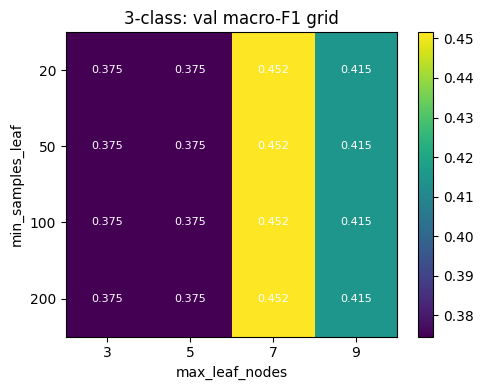

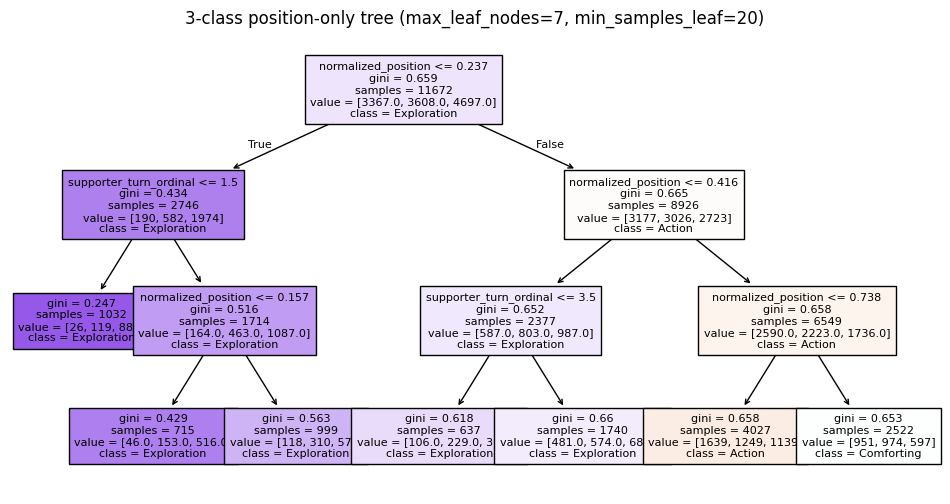

In [6]:
grid_df_3c = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in grid_results_3c])
pivot_3c = grid_df_3c.pivot(index="min_samples_leaf", columns="max_leaf_nodes", values="val_macro_f1")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot_3c.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot_3c.columns))); ax.set_xticklabels(pivot_3c.columns)
ax.set_yticks(range(len(pivot_3c.index))); ax.set_yticklabels(pivot_3c.index)
ax.set_xlabel("max_leaf_nodes"); ax.set_ylabel("min_samples_leaf")
ax.set_title("3-class: val macro-F1 grid")
for i in range(pivot_3c.shape[0]):
    for j in range(pivot_3c.shape[1]):
        ax.text(j, i, f"{pivot_3c.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(tree_3c, feature_names=FEATURE_NAMES, class_names=COARSE_LABELS, filled=True, fontsize=8, ax=ax)
ax.set_title(f"3-class position-only tree (max_leaf_nodes={best_3c['max_leaf_nodes']}, min_samples_leaf={best_3c['min_samples_leaf']})")
plt.show()


**Results (both tasks):**

| Task | Selected hyperparameters | Depth / leaves | Val macro-F1 | Test macro-F1 |
|---|---|---|---|---|
| 8-class | max_leaf_nodes=20, min_samples_leaf=100 | 8 / 20 | 0.1771 | 0.1795 |
| 3-class | max_leaf_nodes=7, min_samples_leaf=20 | 3 / 7 | 0.4515 | 0.4418 |

Feature importances: `normalized_position` dominates both tasks (0.975 on
8-class, 0.918 on 3-class) -- `supporter_turn_ordinal` adds little once
position is available (the two are correlated: later position in a
conversation implies a higher supporter-turn count), though it carries
more weight on 3-class (8.2%) than 8-class (2.5%).

**8-class:** position alone clearly trails the text-based approaches (0.1795
vs. TF-IDF 0.2189, RoBERTa 0.2398). At only 20 leaves it never predicts 4 of
the 8 classes at all (Information, Reflection of feelings, Restatement or
Paraphrasing, Self-disclosure all get precision=recall=0) -- a real, honest
limitation: these four strategies aren't position-determined the way
Question/Others/Providing Suggestions/Affirmation and Reassurance partially
are, so with only 2 low-cardinality features and a small leaf budget they
get folded entirely into whichever majority-class prediction dominates
their position range.

**3-class -- notable result, though the specific ranking changed after a
later fix:** against the ORIGINAL RoBERTa checkpoint, the position-only
tree (0.4418 test) edged it out (0.4395 test). After RoBERTa was retrained
with a speaker-tag preprocessing fix (see report_notes.md "AI was wrong"
#3), RoBERTa reclaimed the lead: 0.4463 test > 0.4418. The tree still beats
DistilBERT (0.4269 test) and the TF-IDF baseline (0.4217 single-seed /
0.4293 20-seed mean) using *zero text*, and the underlying point still
holds: the 8->3 coarse mapping was itself built around measured mean
normalized turn position (see `preprocessing.py` docstring:
Exploration/Comforting/Action strategies were resolved into
position-ordered bands), so getting within ~0.004 of a fine-tuned
transformer using zero text is still a striking, reportable result --
reporting BOTH the pre-fix (tree wins) and post-fix (RoBERTa wins) numbers
is more honest than only showing whichever is currently true, since the
reversal itself is evidence the fix had a real effect.

*(Numbers above reflect a `turn_index` bugfix in `preprocessing.py` -- see report_notes.md "AI was wrong" #4. Effect was negligible: 3-class test score is bit-for-bit unchanged (0.4418), 8-class test moved 0.1791->0.1795.)*

## 2. TF-IDF + LogReg baseline

Reuses the exact evaluation function from `01_split_protocol.ipynb`,
generalized to take a label key / example builder so it works for both
tasks without duplicating the leakage-test-specific code there.

In [7]:
def evaluate_tfidf_logreg(train, test, label_key, target_names, label=""):
    X_train_text = [flatten_context(ex["context"], include_speaker_tags=False) for ex in train]
    X_test_text = [flatten_context(ex["context"], include_speaker_tags=False) for ex in test]
    y_train = [ex[label_key] for ex in train]
    y_test = [ex[label_key] for ex in test]

    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), token_pattern=CONTRACTION_TOKEN_PATTERN)
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    print(f"--- {label} ---")
    print(f"Train: {len(train)}  Test: {len(test)}")
    print(f"Macro-F1 (test): {macro_f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    return macro_f1, np.array(y_test), np.array(y_pred)


### 8-class, single seed=42 (official split, same seed as every DL run)

In [8]:
tfidf_8c_macro_f1, y_test_8c, y_pred_8c = evaluate_tfidf_logreg(
    train_8c, test_8c, "gold_strategy_id", STRATEGY_LABELS, label="8-class TF-IDF+LogReg (seed=42)"
)


--- 8-class TF-IDF+LogReg (seed=42) ---
Train: 14190  Test: 1724
Macro-F1 (test): 0.2189
                             precision    recall  f1-score   support

Affirmation and Reassurance       0.21      0.19      0.20       267
                Information       0.08      0.12      0.10        96
                     Others       0.43      0.36      0.39       307
      Providing Suggestions       0.23      0.23      0.23       283
                   Question       0.54      0.35      0.42       334
     Reflection of feelings       0.08      0.10      0.09       142
Restatement or Paraphrasing       0.17      0.29      0.21       126
            Self-disclosure       0.11      0.11      0.11       169

                   accuracy                           0.25      1724
                  macro avg       0.23      0.22      0.22      1724
               weighted avg       0.28      0.25      0.26      1724



### 8-class, 20-seed mean (matches the 3-class treatment in 01_split_protocol.ipynb)

In [9]:
# Inlined (not reusing evaluate_tfidf_logreg) to avoid printing 20 full
# classification reports -- only the aggregate macro-F1 is needed per seed.
def quick_macro_f1(train, test, label_key):
    X_train_text = [flatten_context(ex["context"], include_speaker_tags=False) for ex in train]
    X_test_text = [flatten_context(ex["context"], include_speaker_tags=False) for ex in test]
    y_train = [ex[label_key] for ex in train]
    y_test = [ex[label_key] for ex in test]
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), token_pattern=CONTRACTION_TOKEN_PATTERN)
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return f1_score(y_test, y_pred, average="macro", zero_division=0)

N_REPEATS = 20
f1s_8c = []
for seed in range(N_REPEATS):
    train, val, test = apply_conversation_level_split(convs, examples_8c, seed=seed)
    f1s_8c.append(quick_macro_f1(train, test, "gold_strategy_id"))

f1s_8c = np.array(f1s_8c)
print(f"8-class TF-IDF+LogReg macro-F1 across {N_REPEATS} seeds: mean={f1s_8c.mean():.4f}  std={f1s_8c.std():.4f}")


8-class TF-IDF+LogReg macro-F1 across 20 seeds: mean=0.2264  std=0.0117


**Result summary:**

| Task | Single seed=42 | 20-seed mean (std) |
|---|---|---|
| 3-class | 0.4217 | 0.4293 (0.0136) |
| 8-class | 0.2189 | 0.2264 (0.0117) |

*(Numbers reflect a token_pattern fix to TfidfVectorizer -- sklearn's default
tokenizer splits on apostrophes, so "we're" became "we"+"re" and "that's"
silently dropped its "s". Fixed to keep contractions whole; re-ran all
TF-IDF+LogReg cells across this notebook and 01_split_protocol.ipynb. Old
numbers: 3-class 0.4138 / 0.4289, 8-class 0.2213 / 0.2267 -- superseded, kept
here for the audit trail. Effect was small and did not change any ranking.)*


## 3. DL classifier test-set evaluation

Run these once each, from a terminal, before continuing (inference-only,
fine on CPU -- see `src/evaluate.py` docstring):

```
python evaluate.py test --task 8class --checkpoint ../outputs/8class/roberta/lr1e-5_wd0.01/best_model --name roberta --speaker_tags
python evaluate.py test --task 3class --checkpoint ../outputs/3class/roberta/lr1e-5_wd0.01/best_model --name roberta --speaker_tags
```

Each call writes `outputs/{task}/roberta/{test_predictions.csv, classification_report.txt, confusion_matrix.csv}`.
This is the single official test-set touch for this checkpoint -- these
numbers are final, not a basis for further tuning. (DistilBERT was also
evaluated on test during development -- see report_notes.md for those
numbers -- but is dropped from this notebook to keep it focused on the
final model, RoBERTa, for both tasks.)

In [10]:
CHECKPOINTS = {
    ("8class", "roberta"): "roberta (final 8-class model)",
    ("3class", "roberta"): "roberta (final 3-class model)",
}

outputs_root = Path("..") / "outputs"
results = {}
for (task, name), desc in CHECKPOINTS.items():
    path = outputs_root / task / name / "test_predictions.csv"
    if not path.exists():
        print(f"MISSING: {path} -- run evaluate.py test for ({task}, {name}) first")
        continue
    df = pd.read_csv(path)
    results[(task, name)] = df
    macro_f1 = f1_score(df["true_label_id"], df["pred_label_id"], average="macro", zero_division=0)
    print(f"{task:8s} {name:12s} ({desc:30s})  test macro-F1 = {macro_f1:.4f}  n={len(df)}")


8class   roberta      (roberta (final 8-class model) )  test macro-F1 = 0.2398  n=1724
3class   roberta      (roberta (final 3-class model) )  test macro-F1 = 0.4463  n=1417


### RoBERTa official test-set result (both tasks)

In [11]:
from sklearn.metrics import precision_recall_fscore_support as _prfs

def roberta_test_table(task, target_names):
    df = results[(task, "roberta")]
    macro_f1 = f1_score(df["true_label_id"], df["pred_label_id"], average="macro", zero_division=0)
    p, r, f1, support = _prfs(df["true_label_id"], df["pred_label_id"], labels=list(range(len(target_names))), zero_division=0)
    table = pd.DataFrame({"label": target_names, "precision": p, "recall": r, "f1": f1, "support": support})
    print(f"{task} / roberta -- TEST macro-F1 = {macro_f1:.4f}")
    return table

roberta_8class_table = roberta_test_table("8class", STRATEGY_LABELS)
roberta_8class_table


8class / roberta -- TEST macro-F1 = 0.2398


,label,precision,recall,f1,support
0,Affirmation and Reassurance,0.235294,0.149813,0.183066,267
1,Information,0.081218,0.166667,0.109215,96
2,Others,0.454545,0.390879,0.420315,307
3,Providing Suggestions,0.261224,0.226148,0.242424,283
4,Question,0.492013,0.461078,0.476043,334
5,Reflection of feelings,0.140909,0.218310,0.171271,142
6,Restatement or Paraphrasing,0.241935,0.119048,0.159574,126
7,Self-disclosure,0.130435,0.195266,0.156398,169


In [12]:
roberta_3class_table = roberta_test_table("3class", COARSE_LABELS)
roberta_3class_table


3class / roberta -- TEST macro-F1 = 0.4463


,label,precision,recall,f1,support
0,Action,0.370370,0.422164,0.394575,379
1,Comforting,0.370236,0.467890,0.413374,436
2,Exploration,0.633641,0.456811,0.530888,602


### Confusion matrices

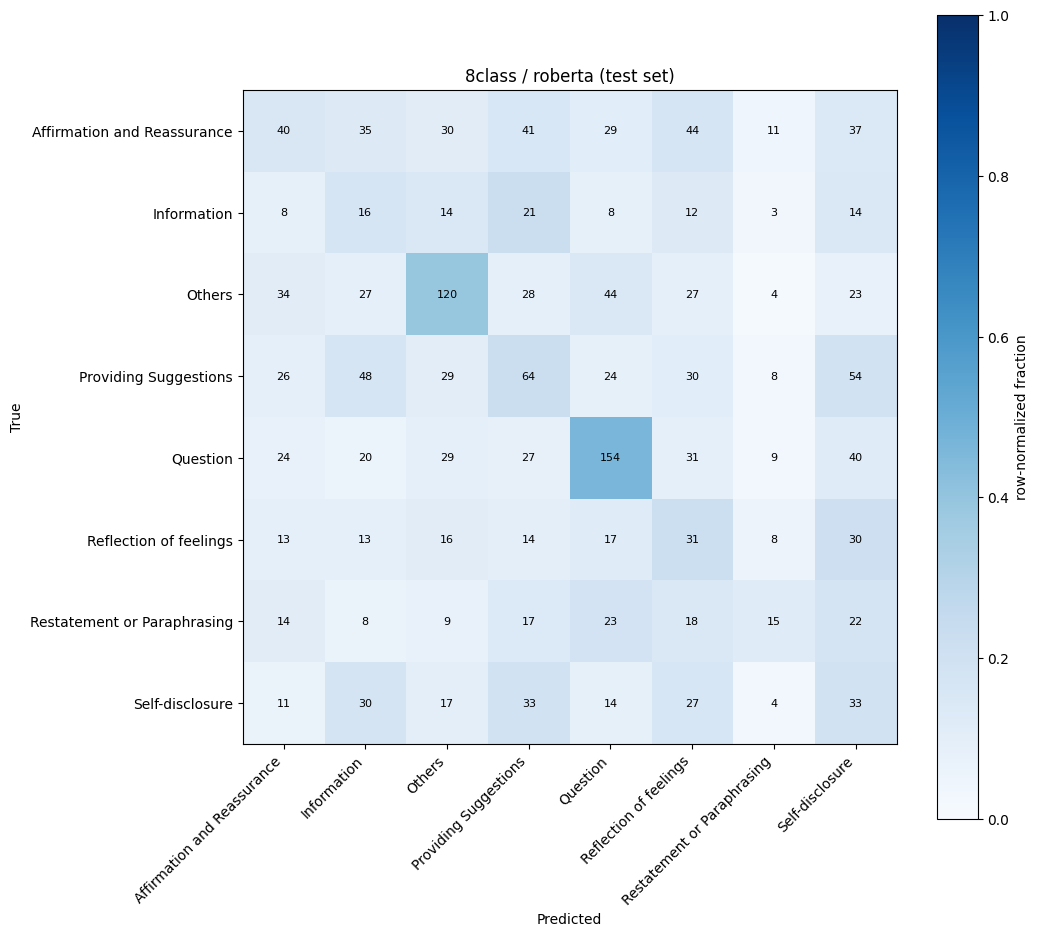

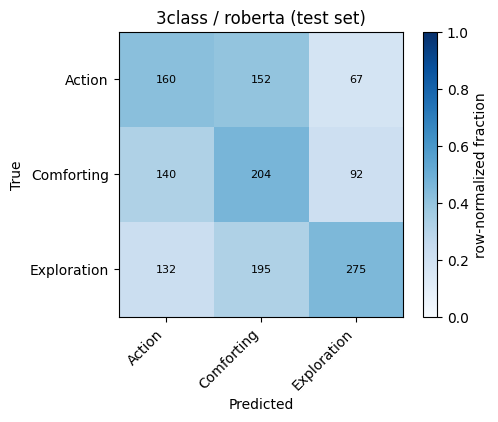

In [13]:
def plot_confusion(df, target_names, title):
    cm = confusion_matrix(df["true_label_id"], df["pred_label_id"], labels=list(range(len(target_names))))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(1.1 * len(target_names) + 2, 1.1 * len(target_names) + 1))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names, rotation=45, ha="right")
    ax.set_yticklabels(target_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                     color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label="row-normalized fraction")
    fig.tight_layout()
    return fig

for task, target_names in [("8class", STRATEGY_LABELS), ("3class", COARSE_LABELS)]:
    key = (task, "roberta")
    if key in results:
        plot_confusion(results[key], target_names, f"{task} / roberta (test set)")
        plt.show()


**Results:**

| Task | RoBERTa test macro-F1 (post speaker-tag fix) | Val | Test (pre-fix, superseded) |
|---|---|---|---|
| 8-class | 0.2398 | 0.2493 | 0.2413 |
| 3-class | 0.4463 | 0.4496 | 0.4395 |

8-class test moved slightly down from the pre-fix number (-0.0015,
essentially flat/noise against a val improvement of +0.0091). 3-class
improved on both val (+0.0087) and test (+0.0068), consistently -- the
stronger signal that the speaker-tag fix has a real, positive effect. See
report_notes.md "RoBERTa speaker-tag retrain (final numbers)" for the full
writeup, including why this is a legitimate second official test touch
(a genuine preprocessing bug fix, not dissatisfaction with the first
result) and both old and new numbers kept for the audit trail.

Full ranking, all baselines/models, this test split (post-fix):

- **8-class:** RoBERTa 0.2398 > TF-IDF 0.2189 > position tree 0.1795
  (DistilBERT, comparison point only: 0.2174, pending re-eval on tagged input)
- **3-class:** RoBERTa 0.4463 > position tree 0.4418 > TF-IDF (20-seed mean)
  0.4293 > DistilBERT 0.4269 (comparison point only, pending re-eval on tagged input)

RoBERTa now leads on both tasks. Still worth keeping the decision-tree
section's pre-fix number in view -- for the coarse 3-class task,
conversational stage alone (zero text) landed within ~0.004 of a
fine-tuned transformer at one point in the process, which remains good
supporting evidence the 3-class mapping decision (itself position-based)
was sound, even though RoBERTa is back in front now.

**Next:** pull specific `correct == False` rows from `test_predictions.csv`
(both tasks) for the ~10-item hand-read error analysis -- prioritize rows
where RoBERTa is *confident and wrong* (high `confidence`, `correct=False`),
since those are the most diagnostically interesting failures.

## Per-class results & label-skew reporting

Assignment requirement: "Report per-class results, not only aggregates -
the label distribution is heavily skewed and an aggregate number alone will
not be accepted." Two complementary views below, both for RoBERTa (the
final model, both tasks):

1. **Distribution comparison** -- true label %, RoBERTa's predicted label %,
   and a uniform-baseline % (1/n_classes), all three overlaid per class, per
   task. Shows at a glance whether the model tracks the real (skewed)
   distribution or defaults toward majority classes -- and how far a
   "predicts nothing, guesses uniformly" baseline would be from reality.
2. **Per-class precision/recall/F1 + support** -- the actual per-class
   metric table/chart the assignment is asking for, with support (n) shown
   alongside so it's clear which classes are data-starved vs well-represented.

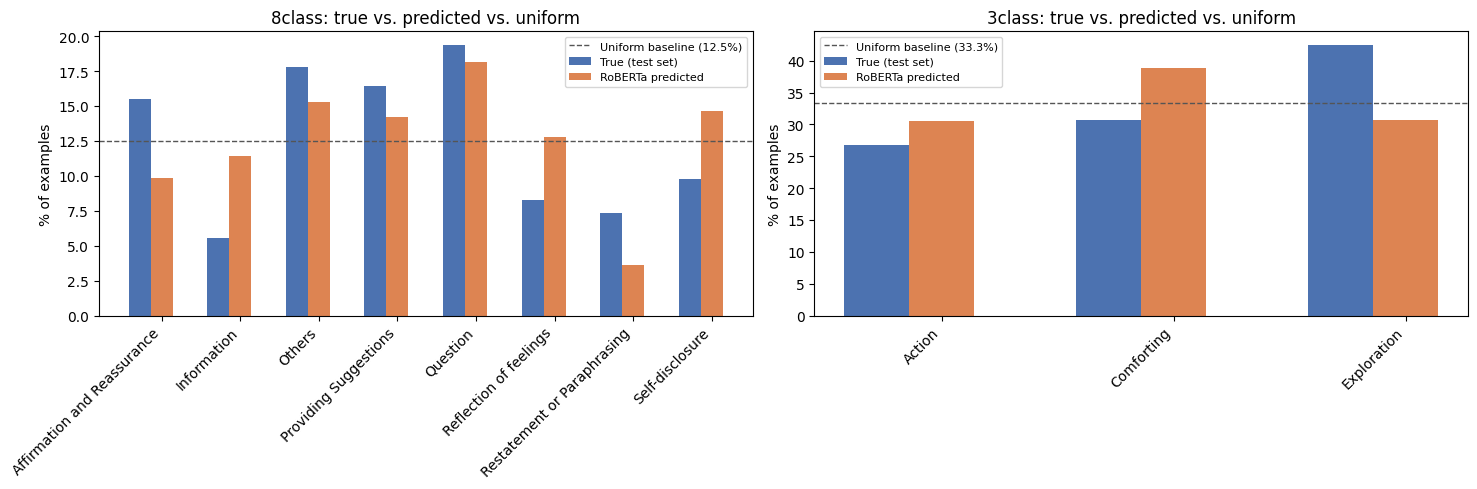

In [14]:
import numpy as np

def class_distributions(task, target_names, label_key_id="true_label_id", pred_key_id="pred_label_id"):
    df = results[(task, "roberta")]
    n = len(target_names)
    true_counts = df[label_key_id].value_counts().reindex(range(n), fill_value=0)
    pred_counts = df[pred_key_id].value_counts().reindex(range(n), fill_value=0)
    true_pct = 100 * true_counts / true_counts.sum()
    pred_pct = 100 * pred_counts / pred_counts.sum()
    uniform_pct = 100 / n
    return true_pct.values, pred_pct.values, uniform_pct


def plot_distribution_comparison(task, target_names, ax):
    true_pct, pred_pct, uniform_pct = class_distributions(task, target_names)
    x = np.arange(len(target_names))
    width = 0.28
    ax.bar(x - width, true_pct, width, label="True (test set)", color="#4C72B0")
    ax.bar(x, pred_pct, width, label="RoBERTa predicted", color="#DD8452")
    ax.axhline(uniform_pct, color="#555555", linestyle="--", linewidth=1, label=f"Uniform baseline ({uniform_pct:.1f}%)")
    ax.set_xticks(x)
    ax.set_xticklabels(target_names, rotation=45, ha="right")
    ax.set_ylabel("% of examples")
    ax.set_title(f"{task}: true vs. predicted vs. uniform")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_distribution_comparison("8class", STRATEGY_LABELS, axes[0])
plot_distribution_comparison("3class", COARSE_LABELS, axes[1])
plt.tight_layout()
plt.savefig("label_distribution_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

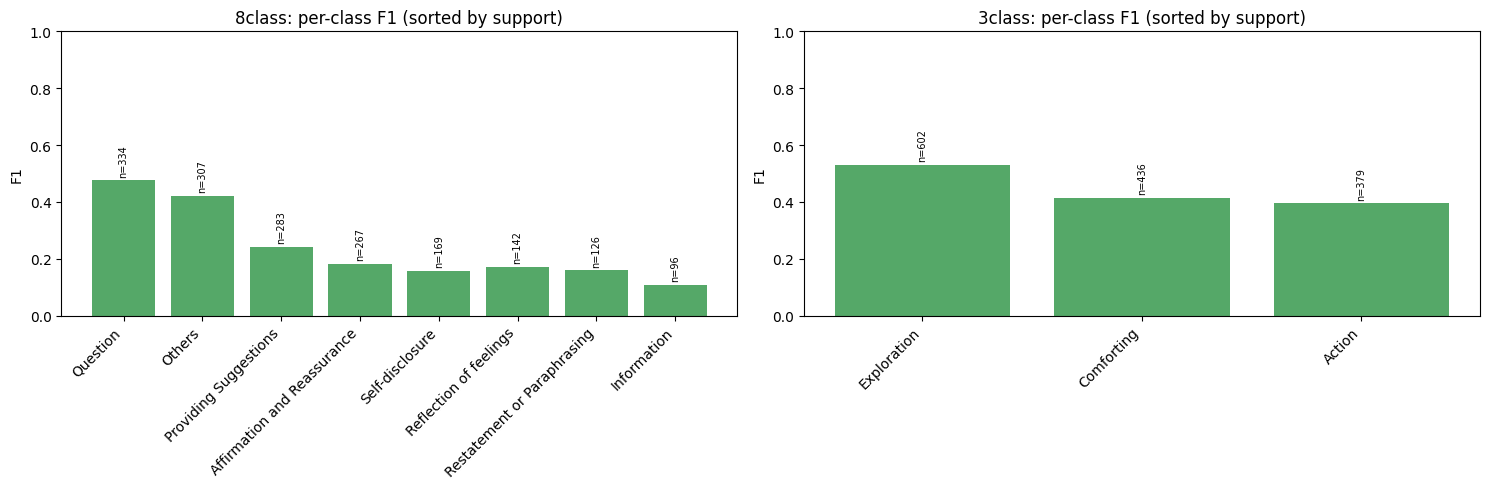

8-class per-class table:
                      label  precision   recall       f1  support
                   Question   0.492013 0.461078 0.476043      334
                     Others   0.454545 0.390879 0.420315      307
      Providing Suggestions   0.261224 0.226148 0.242424      283
Affirmation and Reassurance   0.235294 0.149813 0.183066      267
            Self-disclosure   0.130435 0.195266 0.156398      169
     Reflection of feelings   0.140909 0.218310 0.171271      142
Restatement or Paraphrasing   0.241935 0.119048 0.159574      126
                Information   0.081218 0.166667 0.109215       96

3-class per-class table:
      label  precision   recall       f1  support
Exploration   0.633641 0.456811 0.530888      602
 Comforting   0.370236 0.467890 0.413374      436
     Action   0.370370 0.422164 0.394575      379


In [15]:
def per_class_table(task, target_names):
    df = results[(task, "roberta")]
    p, r, f1, support = _prfs(df["true_label_id"], df["pred_label_id"], labels=list(range(len(target_names))), zero_division=0)
    table = pd.DataFrame({"label": target_names, "precision": p, "recall": r, "f1": f1, "support": support})
    table = table.sort_values("support", ascending=False).reset_index(drop=True)
    return table

per_class_8c = per_class_table("8class", STRATEGY_LABELS)
per_class_3c = per_class_table("3class", COARSE_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, table, task in [(axes[0], per_class_8c, "8class"), (axes[1], per_class_3c, "3class")]:
    x = np.arange(len(table))
    ax.bar(x, table["f1"], color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(table["label"], rotation=45, ha="right")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1)
    ax.set_title(f"{task}: per-class F1 (sorted by support)")
    for i, (f1v, sup) in enumerate(zip(table["f1"], table["support"])):
        ax.text(i, f1v + 0.02, f"n={sup}", ha="center", fontsize=7, rotation=90)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=120, bbox_inches="tight")
plt.show()

print("8-class per-class table:")
print(per_class_8c.to_string(index=False))
print()
print("3-class per-class table:")
print(per_class_3c.to_string(index=False))

**Results (real, post-run):**

8-class per-class F1, sorted by support:

| Label | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Question | 0.492 | 0.461 | 0.476 | 334 |
| Others | 0.455 | 0.391 | 0.420 | 307 |
| Providing Suggestions | 0.261 | 0.226 | 0.242 | 283 |
| Affirmation and Reassurance | 0.235 | 0.150 | 0.183 | 267 |
| Self-disclosure | 0.130 | 0.195 | 0.156 | 169 |
| Reflection of feelings | 0.141 | 0.218 | 0.171 | 142 |
| Restatement or Paraphrasing | 0.242 | 0.119 | 0.160 | 126 |
| Information | 0.081 | 0.167 | 0.109 | 96 |

3-class per-class F1:

| Label | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Exploration | 0.634 | 0.457 | 0.531 | 602 |
| Comforting | 0.370 | 0.468 | 0.413 | 436 |
| Action | 0.370 | 0.422 | 0.395 | 379 |

**Why the aggregate alone is misleading here (the assignment's exact
concern):** 8-class accuracy is 27% (see the classification report a few
cells up) and weighted-F1 is 0.28 -- both inflated by the two largest
classes (Question, Others -- 36% of the test set combined) performing
reasonably (F1 0.42-0.48). Macro-F1 (0.2398, unweighted mean across all 8
classes) is dragged down hard by the bottom four: Information (F1=0.109,
smallest class, n=96), Restatement or Paraphrasing (0.160), Self-disclosure
(0.156), Reflection of feelings (0.171) -- all below 0.20 despite
Restatement/Self-disclosure/Reflection having *more* support than
Information, which rules out "small class" as the only explanation. These
three sit in a narrow, semantically overlapping band (paraphrasing what the
seeker said vs. reflecting their feelings vs. sharing a personal anecdote --
all supportive-listening moves that likely look similar in raw text),
plausibly harder to separate from each other than from the more
distinctively-worded classes (Question, Providing Suggestions). This is
exactly the kind of finding an aggregate number hides and per-class
reporting surfaces.

3-class is less extreme (all three F1s within 0.53-0.39, no class near
zero) but still shows the same pattern in miniature: Exploration has by far
the best precision (0.634) but the worst recall (0.457) of the three --
RoBERTa is conservative about predicting Exploration (only calls it when
fairly confident) at the cost of missing many true Exploration examples,
while Comforting/Action are called more liberally (higher recall, lower
precision). Worth noting in the report as a precision/recall tradeoff, not
just a single F1 number.

**Distribution comparison (previous cell), checked against the actual
true/predicted percentages, not just the plot by eye:**

3-class fits a clean "compressed toward uniform" pattern: true =
Action 26.7% / Comforting 30.8% / Exploration 42.5%, predicted =
30.5% / 38.9% / 30.6% -- the largest class (Exploration) is pulled down
hard toward the 33.3% uniform line, the two smaller classes pulled up.
Consistent with the `class_weight="balanced"`-style loss weighting used
during training (see `train_roberta.py`'s `compute_class_weights`), which
explicitly counteracts the skew rather than learning it -- direct visual
evidence that weighting is having its intended effect.

8-class mostly fits the same pattern (e.g. Information, true=5.6% ->
pred=11.4%, over-predicted; Question, true=19.4% -> pred=18.2%, the
largest class nudged down) but **not uniformly** -- Restatement or
Paraphrasing is the clear exception: true=7.3% but predicted only 3.6%,
i.e. a small class that got *further* suppressed, not pulled toward
uniform like the others. This lines up with it having the lowest recall of
any 8-class label (0.119, per-class table above) -- the model essentially
avoids predicting this class at all, rather than over-calling it the way
class-weighting would predict for a minority class. Worth reporting this as
a genuine exception rather than smoothing it into "the pattern holds" --
it's a real, specific weakness (Restatement or Paraphrasing is apparently
hard to recognize on its own text, likely confusable with Reflection of
feelings and Self-disclosure, the other two weak, semantically-adjacent
classes), not just noise.

## Interpretability / explainability

Assignment requirement: "interpretability / explainability of the proposed
model's behavior." Three methods, matched to what each model actually is:

1. **Decision tree** -> tree plot (section 1 above) -- the model IS its own
   explanation, no separate method needed.
2. **TF-IDF + LogReg** -> top positive coefficients per class, directly from
   the fitted linear model -- this section.
3. **RoBERTa** (final model) -> Integrated Gradients (primary) + Occlusion
   (cross-check), via `captum` -- per-example, token-level attributions on
   confident-but-wrong predictions. Requires a local run with `captum`
   installed (see markdown below); not run inline in this notebook.

Considered and deliberately NOT using raw attention weights as primary
evidence for RoBERTa: attention weights are a popular but contested
interpretability signal -- Jain & Wallace 2019 ("Attention is not
Explanation", NAACL) show attention distributions can be adversarially
perturbed without changing the prediction, while Wiegreffe & Pinter 2019
("Attention is not not Explanation", EMNLP) push back that attention can
still be a *plausible* explanation under the right diagnostic tests. Rather
than adjudicate that debate, this project uses gradient-based attribution
(Integrated Gradients), which has a cleaner theoretical grounding
(completeness axiom: attributions sum exactly to the prediction-vs-baseline
difference) and isn't subject to the same critique.

### TF-IDF + LogReg: top coefficients per class

Refits the same TF-IDF+LogReg pipeline used for the baseline numbers above
(same config, same seed=42, train split only) and inspects
`LogisticRegression.coef_` directly -- for a linear model, the coefficients
themselves ARE the explanation, no separate attribution method needed.

In [16]:
def fit_tfidf_logreg(build_fn, label_key):
    ex = build_fn(convs)
    train, val, test = apply_conversation_level_split(convs, ex, seed=42)
    Xtr_text = [flatten_context(e["context"], include_speaker_tags=False) for e in train]
    ytr = [e[label_key] for e in train]
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), token_pattern=CONTRACTION_TOKEN_PATTERN)
    Xtr = vectorizer.fit_transform(Xtr_text)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    clf.fit(Xtr, ytr)
    return vectorizer, clf

def top_coefficients(vectorizer, clf, n=10):
    feat_names = np.array(vectorizer.get_feature_names_out())
    top = {}
    for i, cls in enumerate(clf.classes_):
        coefs = clf.coef_[i]
        top_idx = np.argsort(coefs)[-n:][::-1]
        top[cls] = list(feat_names[top_idx])
    return top

vec_8c, clf_8c = fit_tfidf_logreg(build_8class_examples, "gold_strategy")
vec_3c, clf_3c = fit_tfidf_logreg(build_3class_examples, "gold_coarse")
top_8c = top_coefficients(vec_8c, clf_8c)
top_3c = top_coefficients(vec_3c, clf_3c)

print("8-class top coefficients per class:")
for cls, words in top_8c.items():
    print(f"  {cls:30s}: {', '.join(words)}")
print("\n3-class top coefficients per class:")
for cls, words in top_3c.items():
    print(f"  {cls:30s}: {', '.join(words)}")

print("\nCross-check: do 8-class sub-strategies agree with their 3-class parent?")
for coarse in COARSE_LABELS:
    members = [k for k, v in STRATEGY_TO_COARSE.items() if v == coarse]
    print(f"\n{coarse} <- {members}")
    for m in members:
        print(f"    {m:30s}: {top_8c[m][:6]}")
    print(f"    [3class] {coarse:20s}: {top_3c[coarse][:6]}")

8-class top coefficients per class:
  Affirmation and Reassurance   : we're, helpful, with my, to help, feels, said, true, word, that, thoughts
  Information                   : what kind, qualified, interesting, thanks you, bye, wow, afraid, where do, therapist, things
  Others                        : you, thanks, hello, bye, have good, thanks for, will, your, that's, appreciate
  Providing Suggestions         : do, understanding, with that, to make, to, them, usually, how to, it would, her
  Question                      : hello, hi, how are, hey, sad, been better, not, hello how, sorry to, pretty
  Reflection of feelings        : counseling, during, said, plans, they are, correct, very bad, friend, tell, anymore
  Restatement or Paraphrasing   : lately, how are, am, my, not so, sleeping, very true, is not, i'm, three
  Self-disclosure               : how did, what are, have you, to this, you ever, did you, want to, about your, helpful, to

3-class top coefficients per class:
  Acti

**Results (real, post-run):** see report_notes.md "TF-IDF interpretability
(top coefficients)" for the full writeup. Two findings worth stating in the
report:

1. **The 3-class model's top words track whichever 8-class sub-strategy has
   more TRAIN-set support, not an even blend.** (Using train counts here,
   not the test-set support shown in the per-class table above, since
   that's what the coefficients are actually fit on.) Action's top words
   ("check", "with that", "usually", "suggestions") echo Providing
   Suggestions (train n=2359) far more than Information (train n=1008) --
   "with that" and "usually" appear verbatim in both lists. Exploration's
   top words ("hi", "hello", "how are") match Question (train n=2659)
   almost exactly, not Restatement or Paraphrasing (train n=866) or
   Reflection of feelings (train n=1172). Comforting blends more evenly
   (its two sources, train n=2242 and 1366, are closer in size, ~1.6x vs.
   ~2.3x+ for the other two) -- consistent with "closer support -> more
   even blend." This is defensible evidence the two granularities agree
   where it matters (the dominant sub-signal carries through), while also
   revealing the coarse labels aren't a clean semantic average of their
   components -- they're support-weighted in practice.
2. **Many top-ranked words are conversational position markers, not
   content words** -- "hi"/"hello"/"hey" for Question, "bye"/"thanks"/
   "goodbye" for Others. These are the exact opening/closing phrases
   already catalogued in `00_explore_data.ipynb`'s greeting/closing-phrase
   analysis. Ties directly to the position-tree baseline's finding that
   `normalized_position` alone explains most of the signal for several
   classes -- TF-IDF is (in part) independently re-discovering the same
   positional structure through vocabulary, not a coincidence.

**Tokenizer fix (applied before the numbers above were generated):** sklearn's default `TfidfVectorizer` token pattern splits on apostrophes -- "we're" became separate tokens "we"/"re", and "that's" silently dropped its "s" (single-char tokens are filtered). Fixed via a custom `token_pattern` that keeps contractions whole; applied everywhere TfidfVectorizer is used (this notebook and 01_split_protocol.ipynb), not just here, since it also affects the reported TF-IDF+LogReg baseline score, not only these coefficient lists -- see the Result summary table above for old vs. new baseline numbers. The findings above are unchanged qualitatively (e.g. "we're" now shows up whole in Affirmation and Reassurance / Comforting instead of as two separate, confusing fragments), just cleaner to read.

### RoBERTa interpretability (Integrated Gradients + Occlusion)

Run `src/evaluate.py interpret` first (needs `captum`: `pip install
captum`; needs the RoBERTa checkpoints -- CPU is fine, same class of
workload as `evaluate.py test`):

```
python evaluate.py interpret --task 8class --checkpoint ../outputs/8class/roberta/lr1e-5_wd0.01/best_model
python evaluate.py interpret --task 3class --checkpoint ../outputs/3class/roberta/lr1e-5_wd0.01/best_model
```

That writes `outputs/{task}/roberta/interpretability_data.json` -- the cell
below reads that JSON and renders it. This cell itself needs no torch/captum
(same reasoning as the TF-IDF cells above: heavy one-off computation stays
in the script, the notebook just renders precomputed numbers), so re-running
it costs nothing. Two groups per task: confident-but-WRONG (same 5 examples
that will anchor the hand-read error analysis) and confident-and-CORRECT (a
3-example contrast set, so the report can show what "right for the right
reason" looks like next to a confident failure).

In [20]:
import json
import html as html_lib
from IPython.display import HTML, display

def clean_token_text(tok):
    """RoBERTa's byte-level BPE: 'Ġ' marks a leading space, 'Ċ' a newline --
    see report_notes.md "TF-IDF tokenizer fix" for the contrast with how
    TF-IDF's tokenizer handles this differently."""
    return tok.replace("\u0120", " ").replace("\u010a", "\n")

def render_ig_tokens(tokens, scores):
    max_abs = max([abs(s) for s in scores], default=1.0) or 1.0
    out = []
    for tok, score in zip(tokens, scores):
        if tok in ("<s>", "</s>", "<pad>"):
            continue  # dropped for the report-ready view -- no interpretive signal, just clutter
        text = clean_token_text(tok)
        s = max(-1.0, min(1.0, score / max_abs))
        bg = (f"rgba(34,139,74,{0.12+0.55*s:.2f})" if s >= 0
              else f"rgba(200,50,50,{0.12+0.55*abs(s):.2f})")
        out.append(f'<span class="tok" style="background-color:{bg};">{html_lib.escape(text)}</span>')
    return "".join(out)

def render_occlusion_chips(top):
    chips = []
    for tok, drop in top[:6]:
        text = clean_token_text(tok).strip()
        chips.append(f'<span class="chip">{html_lib.escape(text)} <b>{drop:+.3f}</b></span>')
    return "".join(chips)

def render_example_card(ex, kind):
    badge_class = "badge-wrong" if kind == "wrong" else "badge-correct"
    badge_text = "WRONG" if kind == "wrong" else "CORRECT"
    ig_html = render_ig_tokens(ex["tokens"], ex["ig_scores"])
    occ_html = render_occlusion_chips(ex["occlusion_top"])
    return f'''
    <div class="example-card">
      <div class="example-header">
        <span class="badge {badge_class}">{badge_text}</span>
        <span class="meta">true: <b>{html_lib.escape(ex["true_label"])}</b> &nbsp;&middot;&nbsp;
        pred: <b>{html_lib.escape(ex["pred_label"])}</b> &nbsp;&middot;&nbsp;
        confidence: <b>{ex["confidence"]:.2f}</b></span>
      </div>
      <div class="ig-text">{ig_html}</div>
      <div class="occlusion-row"><span class="occlusion-label">Most responsible tokens (occlusion):</span> {occ_html}</div>
    </div>'''

def render_group(title, examples, kind):
    cards = "".join(render_example_card(ex, kind) for ex in examples)
    return f'<h3 class="group-title">{title}</h3>{cards}'

INTERP_CSS = '''
<style>
  .interp-wrap { font-family: -apple-system, "Segoe UI", Helvetica, Arial, sans-serif; color:#1a1a1a; max-width: 880px; }
  .interp-wrap h2.section-title { font-size: 20px; margin-bottom: 4px; }
  .interp-wrap .legend { font-size: 13px; color:#555; margin-bottom: 20px; display:flex; align-items:center; gap:14px; }
  .interp-wrap .legend .swatch { display:inline-block; width:14px; height:14px; border-radius:3px; vertical-align:middle; margin-right:4px; }
  .interp-wrap h3.group-title { font-size: 15px; text-transform: uppercase; letter-spacing: 0.04em; color:#666; margin: 22px 0 10px; border-bottom: 1px solid #eee; padding-bottom: 6px; }
  .interp-wrap .example-card { border: 1px solid #e2e2e2; border-radius: 8px; padding: 14px 16px; margin-bottom: 12px; background: #fafafa; }
  .interp-wrap .example-header { display:flex; align-items:center; gap:10px; margin-bottom: 10px; flex-wrap: wrap; }
  .interp-wrap .badge { font-size: 11px; font-weight: 700; padding: 2px 8px; border-radius: 10px; letter-spacing: 0.03em; }
  .interp-wrap .badge-wrong { background:#fde3e3; color:#a12626; }
  .interp-wrap .badge-correct { background:#e1f3e6; color:#1f7a3a; }
  .interp-wrap .meta { font-size: 13px; color:#444; }
  .interp-wrap .ig-text { font-size: 15px; line-height: 2.1; }
  .interp-wrap .tok { padding: 2px 3px; border-radius: 3px; }
  .interp-wrap .occlusion-row { margin-top: 10px; font-size: 12.5px; color:#555; }
  .interp-wrap .occlusion-label { font-weight:600; color:#333; margin-right:6px; }
  .interp-wrap .chip { display:inline-block; background:#eef1f5; border-radius:6px; padding:2px 7px; margin: 2px 3px 2px 0; }
  .interp-wrap .chip b { color:#a12626; }
</style>
'''

def render_roberta_interp(task):
    path = Path("..") / "outputs" / task / "roberta" / "interpretability_data.json"
    data = json.load(open(path, encoding="utf-8"))
    legend = ('<div class="legend"><span><span class="swatch" style="background:rgba(34,139,74,0.55)"></span>'
              'pushes toward the predicted class</span><span><span class="swatch" style="background:rgba(200,50,50,0.55)">'
              '</span>pushes away</span><span>intensity = magnitude</span></div>')
    body = (f'<h2 class="section-title">RoBERTa interpretability -- {task}</h2>{legend}'
            + render_group("Confident but wrong", data["wrong"], "wrong")
            + render_group("Confident and correct (contrast set)", data["correct"], "correct"))
    return INTERP_CSS + f'<div class="interp-wrap">{body}</div>'

#### 8-class

In [21]:
display(HTML(render_roberta_interp("8class")))

#### 3-class

In [22]:
display(HTML(render_roberta_interp("3class")))